<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite SAR Data</span>
## <span style="color:#34495E;">Physics-Informed Double-Bounce Loss Formulation</span>

</div>

The customized loss function is:

$$L_{total} = L_{WCE} + \lambda \cdot L_{physics}$$



<div align="center">

## <span style="color:#16A085;">Project Information</span>

</div>

| **Field**          | **Details**                                    |
|--------------------|------------------------------------------------|
| **Course**         | Deep Learning Project                          |
| **Deliverable**    | <span style="color:#E67E22;">**Deliverable 3 – Model Training & Evaluation**</span> |
| **Authors**        | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz       |
| **Roll Numbers**   | 28100321 & 28100357                            |
| **Approach**       | Approach 5 — Physics-Informed Double-Bounce Loss (PINN) |

---

In [1]:
!pip install -q albumentations tifffile tqdm matplotlib rasterio

In [2]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import tifffile as tiff
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
device      = "cuda" if torch.cuda.is_available() else "cpu"
batch_size  = 8
num_workers = 4
epochs      = 30
lr          = 1e-4
imgsize     = 256
in_channels = 8
num_classes = 3
path        = "/kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation"

backbone    = "cm_unet"
PRE_VH_IDX  = 4
PRE_VV_IDX  = 5
DUR_VH_IDX  = 6
DUR_VV_IDX  = 7

lambda_phys     = 1.0
delta_thresh    = 0.30
specular_thresh = 0.15
exp_scale       = 5.0

classes_name = ["Non-Flooded", "Flooded Open", "Flooded Urban"]

print(f"Device   : {device}")
print(f"Backbone : {backbone}")
print(f"Dataset  : {path}")
print(f"Physics  : λ={lambda_phys}, Δ_thr={delta_thresh}, spec_thr={specular_thresh}, exp_α={exp_scale}")

Device   : cuda
Backbone : cm_unet
Dataset  : /kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation
Physics  : λ=1.0, Δ_thr=0.3, spec_thr=0.15, exp_α=5.0


## <span style="color:#3498DB;">1. Dataset Preparation</span>



In [4]:
class UrbanSARDataset(Dataset):
    def __init__(self, dataset_root, split_file, transform=None):
        self.transform   = transform
        self.image_paths = []
        self.mask_paths  = []
        split_path = os.path.join(dataset_root, split_file)
        if os.path.exists(split_path):
            with open(split_path, "r") as f:
                for line in f.readlines():
                    raw_path = line.strip()
                    if not raw_path:
                        continue
                    path_parts    = raw_path.split('/')
                    clean_base    = os.path.join(*path_parts[-3:])
                    if "GT" in clean_base:
                        clean_gt  = clean_base
                        clean_sar = clean_base.replace("GT", "SAR")
                    else:
                        clean_sar = clean_base
                        clean_gt  = clean_base.replace("SAR", "GT")
                    sar_full = os.path.join(dataset_root, clean_sar)
                    gt_full  = os.path.join(dataset_root, clean_gt)
                    repeats  = 4 if ("Train" in split_file and "03_FU" in clean_base) else 1
                    for _ in range(repeats):
                        self.image_paths.append(sar_full)
                        self.mask_paths.append(gt_full)
        else:
            raise FileNotFoundError(f"Split file not found: {split_path}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with rasterio.open(self.image_paths[index]) as src:
            image = src.read().astype(np.float32)
        with rasterio.open(self.mask_paths[index]) as src:
            mask  = src.read(1).astype(np.int64)
        mask[mask < 0]            = 0
        mask[mask >= num_classes] = 0
        image = np.transpose(image, (1, 2, 0))
        for c in range(in_channels):
            c_min, c_max = image[:, :, c].min(), image[:, :, c].max()
            image[:, :, c] = (image[:, :, c] - c_min) / (c_max - c_min) if c_max > c_min else 0.0
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]
        image = torch.from_numpy(np.transpose(image, (2, 0, 1)).copy()).float()
        mask  = torch.from_numpy(np.array(mask).copy()).long()
        return image, mask

In [5]:
train_transform = A.Compose([
    A.RandomCrop(height=imgsize, width=imgsize),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([
    A.CenterCrop(height=imgsize, width=imgsize),
])

try:
    train_dataset = UrbanSARDataset(path, "Train_dataset.txt", transform=train_transform)
    val_dataset   = UrbanSARDataset(path, "Valid_dataset.txt", transform=val_transform)
    print(f"Train samples : {len(train_dataset)}")
    print(f"Val   samples : {len(val_dataset)}")
except Exception as e:
    print(f"Dataset not loaded: {e}")
    exit(1)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

Train samples : 5914
Val   samples : 1970


## <span style="color:#3498DB;">2. Model Architectures</span>


### A. Plain UNet 

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 8, num_classes: int = 3,
                 features=(64, 128, 256, 512)):
        super().__init__()
        f = features

        # Encoder
        self.enc1  = DoubleConv(in_channels, f[0])
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = DoubleConv(f[0], f[1])
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = DoubleConv(f[1], f[2])
        self.pool3 = nn.MaxPool2d(2)
        self.enc4  = DoubleConv(f[2], f[3])
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(f[3], f[3] * 2)

        # Decoder
        self.up4  = nn.ConvTranspose2d(f[3] * 2, f[3], 2, stride=2)
        self.dec4 = DoubleConv(f[3] * 2, f[3])
        self.up3  = nn.ConvTranspose2d(f[3], f[2], 2, stride=2)
        self.dec3 = DoubleConv(f[2] * 2, f[2])
        self.up2  = nn.ConvTranspose2d(f[2], f[1], 2, stride=2)
        self.dec2 = DoubleConv(f[1] * 2, f[1])
        self.up1  = nn.ConvTranspose2d(f[1], f[0], 2, stride=2)
        self.dec1 = DoubleConv(f[0] * 2, f[0])

        self.out_conv = nn.Conv2d(f[0], num_classes, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b  = self.bottleneck(self.pool4(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out_conv(d1)

In [ ]:
class SpeckleCNNBlock(nn.Module):
_init__(self, in_ch: int, out_ch: int, num_convs: int = 3):
        super().__init__()
        layers, ch = [], in_ch
        for _ in range(num_convs):
            layers += [
                nn.Conv2d(ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            ch = out_ch
        self.conv_block = nn.Sequential(*layers)
        self.residual   = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_block(x) + self.residual(x)

In [ ]:
class MambaSSMBlock(nn.Module):
    def __init__(self, dim: int, d_state: int = 8, d_conv: int = 4, expand: int = 1):
        super().__init__()
        self.dim     = dim
        self.d_state = d_state
        self.d_inner = int(expand * dim)

        self.norm    = nn.LayerNorm(dim)
        self.in_proj = nn.Linear(dim, self.d_inner * 2, bias=False)

        _conv = lambda: nn.Conv1d(self.d_inner, self.d_inner, d_conv,
                                   padding=d_conv - 1, groups=self.d_inner, bias=False)
        self.conv_row = _conv()
        self.conv_col = _conv()

        _xp  = lambda: nn.Linear(self.d_inner, self.d_inner + 2 * d_state, bias=False)
        _dtp = lambda: nn.Linear(self.d_inner, self.d_inner)
        self.x_proj_row,  self.x_proj_col  = _xp(),  _xp()
        self.dt_proj_row, self.dt_proj_col = _dtp(), _dtp()

        A = torch.arange(1, d_state + 1, dtype=torch.float32)
        A = A.unsqueeze(0).expand(self.d_inner, -1)
        self.A_log_row = nn.Parameter(torch.log(A.clone()))
        self.A_log_col = nn.Parameter(torch.log(A.clone()))

        self.D_row = nn.Parameter(torch.ones(self.d_inner))
        self.D_col = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, dim, bias=False)

    def _ssm_scan(self, x, A_log, x_proj, dt_proj, D):
        N, L, d_inner = x.shape
        d_state = A_log.shape[1]
        
        x_fp32 = x.float()
        
        x_dbl            = x_proj(x_fp32)
        dt, B_ssm, C_ssm = x_dbl.split([d_inner, d_state, d_state], dim=-1)
        dt               = F.softplus(dt_proj(dt)).float()
        A                = -torch.exp(A_log.float())

        h  = torch.zeros(N, d_inner, d_state, device=x.device, dtype=torch.float32)
        ys = []
        for t in range(L):
            dA = torch.exp(A.unsqueeze(0) * dt[:, t].unsqueeze(-1))
            dB = dt[:, t].unsqueeze(-1) * B_ssm[:, t].unsqueeze(1)
            h  = dA * h + dB * x_fp32[:, t].unsqueeze(-1)
            y  = (h * C_ssm[:, t].unsqueeze(1)).sum(dim=-1)
            ys.append(y)
        y = torch.stack(ys, dim=1)
        
        y = y + D.float() * x_fp32
        return y.to(x.dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        x_perm = x.permute(0, 2, 3, 1)
        x_norm = self.norm(x_perm)
        xz     = self.in_proj(x_norm)
        x_in, z = xz.chunk(2, dim=-1)

        x_row = x_in.permute(0, 1, 3, 2).reshape(B * H, self.d_inner, W)
        x_row = F.silu(self.conv_row(x_row)[..., :W]).transpose(1, 2)
        y_row = self._ssm_scan(x_row, self.A_log_row, self.x_proj_row,
                                self.dt_proj_row, self.D_row)
        y_row = y_row.reshape(B, H, W, self.d_inner)

        x_col = x_in.permute(0, 2, 3, 1).reshape(B * W, self.d_inner, H)
        x_col = F.silu(self.conv_col(x_col)[..., :H]).transpose(1, 2)
        y_col = self._ssm_scan(x_col, self.A_log_col, self.x_proj_col,
                                self.dt_proj_col, self.D_col)
        y_col = y_col.reshape(B, W, H, self.d_inner).permute(0, 2, 1, 3)

        y = (y_row + y_col) * F.silu(z)
        y = self.out_proj(y).permute(0, 3, 1, 2)
        return x + y


class MambaBottleneck(nn.Module):
    def __init__(self, dim: int, d_state: int = 8, expand: int = 1, num_blocks: int = 2):
        super().__init__()
        self.blocks = nn.ModuleList([
            MambaSSMBlock(dim, d_state=d_state, expand=expand)
            for _ in range(num_blocks)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for blk in self.blocks:
            x = blk(x)
        return x


class CMUNet(nn.Module):
    """CM-UNet: dense CNN encoder + 2-D Mamba bottleneck + skip-connected decoder."""
    def __init__(self, in_channels: int = 8, num_classes: int = 3,
                 features=(64, 128, 256, 512)):
        super().__init__()
        f = features

        self.enc1  = SpeckleCNNBlock(in_channels, f[0], num_convs=3)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2  = SpeckleCNNBlock(f[0], f[1], num_convs=3)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3  = SpeckleCNNBlock(f[1], f[2], num_convs=3)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4  = SpeckleCNNBlock(f[2], f[3], num_convs=3)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = MambaBottleneck(f[3], d_state=8, expand=1, num_blocks=2)

        self.up4   = nn.ConvTranspose2d(f[3], f[2], kernel_size=2, stride=2)
        self.dec4  = SpeckleCNNBlock(f[2] + f[3], f[2], num_convs=2)
        self.up3   = nn.ConvTranspose2d(f[2], f[1], kernel_size=2, stride=2)
        self.dec3  = SpeckleCNNBlock(f[1] + f[2], f[1], num_convs=2)
        self.up2   = nn.ConvTranspose2d(f[1], f[0], kernel_size=2, stride=2)
        self.dec2  = SpeckleCNNBlock(f[0] + f[1], f[0], num_convs=2)
        self.up1   = nn.ConvTranspose2d(f[0], f[0] // 2, kernel_size=2, stride=2)
        self.dec1  = SpeckleCNNBlock(f[0] // 2 + f[0], f[0] // 2, num_convs=2)

        self.out_conv = nn.Conv2d(f[0] // 2, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

In [9]:
if backbone == "unet":
    model = UNet(in_channels=in_channels, num_classes=num_classes).to(device)
elif backbone == "cm_unet":
    model = CMUNet(in_channels=in_channels, num_classes=num_classes).to(device)
else:
    raise ValueError(f"Unknown backbone: {backbone}")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone             : {backbone}")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

with torch.no_grad():
    dummy = torch.randn(2, in_channels, imgsize, imgsize).to(device)
    out   = model(dummy)
    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {out.shape}  ← expected (2, {num_classes}, {imgsize}, {imgsize})")

Backbone             : cm_unet
Total parameters     : 15,824,963
Trainable parameters : 15,824,963
Input  shape : torch.Size([2, 8, 256, 256])
Output shape : torch.Size([2, 3, 256, 256])  ← expected (2, 3, 256, 256)


## <span style="color:#3498DB;">3. Physics-Informed Double-Bounce Loss</span>

This is the **core novelty** of Approach 5. The loss decomposes into:

$$L_{total} = L_{WCE} + \lambda \cdot L_{physics}$$


$$L_{physics} = \frac{1}{|\mathcal{M}_{db}|} \sum_{(i,j) \in \mathcal{M}_{db}} \Big( e^{\alpha \cdot p_0(i,j)} - 1 \Big)$$


In [ ]:
class PhysicsInformedLoss(nn.Module):
    def __init__(
        self,
        class_weights:   torch.Tensor,
        pre_vv_idx:      int   = 0,
        pre_vh_idx:      int   = 1,
        dur_vv_idx:      int   = 2,
        dur_vh_idx:      int   = 3,
        delta_thresh:    float = 0.30,
        specular_thresh: float = 0.15,
        exp_scale:       float = 5.0,
        lambda_phys:     float = 1.0,
    ):
        super().__init__()
        self.wce             = nn.CrossEntropyLoss(weight=class_weights)
        self.pre_vv_idx      = pre_vv_idx
        self.pre_vh_idx      = pre_vh_idx
        self.dur_vv_idx      = dur_vv_idx
        self.dur_vh_idx      = dur_vh_idx
        self.delta_thresh    = delta_thresh
        self.specular_thresh = specular_thresh
        self.exp_scale       = exp_scale
        self.lambda_phys     = lambda_phys

    @torch.no_grad()
    def double_bounce_mask(self, images: torch.Tensor) -> torch.Tensor:
        pre_vv = images[:, self.pre_vv_idx]
        pre_vh = images[:, self.pre_vh_idx]
        dur_vv = images[:, self.dur_vv_idx]
        dur_vh = images[:, self.dur_vh_idx]

        delta_vv  = dur_vv - pre_vv
        delta_vh  = dur_vh - pre_vh
        delta_max = torch.maximum(delta_vv, delta_vh)
        cond_increase = (delta_max > self.delta_thresh).float()

        specular_pixels = (dur_vv < self.specular_thresh).float()
        specular_neigh  = F.max_pool2d(
            specular_pixels.unsqueeze(1), kernel_size=3, stride=1, padding=1
        ).squeeze(1)

        return cond_increase * specular_neigh

    def forward(
        self,
        logits: torch.Tensor,
        masks:  torch.Tensor,
        images: torch.Tensor,
    ):
        l_wce = self.wce(logits, masks)
        db_mask = self.double_bounce_mask(images) 
        prob       = F.softmax(logits, dim=1)
        p_nonflood = prob[:, 0] 
        penalty = torch.exp(self.exp_scale * p_nonflood) - 1.0

        denom   = db_mask.sum().clamp(min=1.0)
        l_phys  = (penalty * db_mask).sum() / denom

        l_total = l_wce + self.lambda_phys * l_phys
        return l_total, l_wce.detach(), l_phys.detach(), db_mask

In [ ]:
_phys_loss_temp = PhysicsInformedLoss(
    class_weights   = torch.tensor([0.1, 0.4, 0.5]).to(device),
    pre_vv_idx      = PRE_VV_IDX,
    pre_vh_idx      = PRE_VH_IDX,
    dur_vv_idx      = DUR_VV_IDX,
    dur_vh_idx      = DUR_VH_IDX,
    delta_thresh    = delta_thresh,
    specular_thresh = specular_thresh,
    exp_scale       = exp_scale,
    lambda_phys     = lambda_phys,
)

_imgs, _msks = next(iter(val_loader))
_imgs        = _imgs.to(device)
_msks_dev    = _msks.to(device)

_db_mask = _phys_loss_temp.double_bounce_mask(_imgs)

total_pix       = _db_mask.numel()
candidate_pix   = int(_db_mask.sum().item())
candidate_frac  = candidate_pix / total_pix

for cls, name in enumerate(classes_name):
    cls_pix = (_msks_dev == cls)
    if cls_pix.sum() == 0:
        print(f"  [{name:<14}] absent in this batch")
        continue
    hit_rate = (_db_mask.bool() & cls_pix).sum().float() / cls_pix.sum().float()
    print(f"  [{name:<14}] physics-mask coverage on this class = {hit_rate.item()*100:.2f}%")

print(f"\nOverall candidate fraction in batch: {candidate_frac*100:.3f}%")
print("Sanity rule of thumb: candidate fraction should be small (< a few %),")
print("and Flooded-Urban coverage should be substantially higher than Non-Flooded.")

del _phys_loss_temp, _db_mask

  [Non-Flooded   ] physics-mask coverage on this class = 0.00%
  [Flooded Open  ] physics-mask coverage on this class = 0.00%
  [Flooded Urban ] physics-mask coverage on this class = 0.00%

Overall candidate fraction in batch: 0.000%
Sanity rule of thumb: candidate fraction should be small (< a few %),
and Flooded-Urban coverage should be substantially higher than Non-Flooded.


## <span style="color:#3498DB;">4. Loss, Optimizer & Scheduler</span>


In [12]:
class_weights = torch.tensor([0.1, 0.4, 0.5]).to(device)
loss_fn       = PhysicsInformedLoss(
    class_weights   = class_weights,
    pre_vv_idx      = PRE_VV_IDX,
    pre_vh_idx      = PRE_VH_IDX,
    dur_vv_idx      = DUR_VV_IDX,
    dur_vh_idx      = DUR_VH_IDX,
    delta_thresh    = delta_thresh,
    specular_thresh = specular_thresh,
    exp_scale       = exp_scale,
    lambda_phys     = lambda_phys,
)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
scaler    = torch.amp.GradScaler("cuda") if device == "cuda" else None

In [13]:
def compute_metrics(preds: torch.Tensor, targets: torch.Tensor, nc: int):
    """Returns per-class IoU and F1 lists (NaN for absent classes)."""
    preds   = torch.argmax(preds, dim=1).view(-1)
    targets = targets.view(-1)
    ious, f1s = [], []
    for cls in range(nc):
        pred_m   = preds == cls
        tgt_m    = targets == cls
        inter    = (pred_m & tgt_m).sum().float()
        union    = pred_m.sum() + tgt_m.sum() - inter
        denom_f1 = pred_m.sum() + tgt_m.sum()
        ious.append((inter / union).item() if union > 0 else float('nan'))
        f1s.append(((2.0 * inter) / denom_f1.float()).item() if denom_f1 > 0 else float('nan'))
    return ious, f1s

## <span style="color:#3498DB;">5. Training Loop</span>

The model is trained for **30 epochs**. Each epoch:


In [ ]:
best_val_loss = float('inf')
history = {
    "train_loss": [], "train_wce": [], "train_phys": [],
    "val_loss":   [], "val_wce":   [], "val_phys":   [],
    "miou":       [], "mf1":       [], "urban_f1":   [],
}

ckpt_best  = f"pinn_{backbone}_best.pth"
ckpt_final = f"pinn_{backbone}_final.pth"

for epoch in range(epochs):
    model.train()
    train_loss, train_wce, train_phys = 0.0, 0.0, 0.0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)

    for images, masks in train_loop:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                preds                       = model(images)
                loss, l_wce, l_phys, _      = loss_fn(preds, masks, images)
            scaler.scale(loss).backward()
            
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
        else:
            preds                  = model(images)
            loss, l_wce, l_phys, _ = loss_fn(preds, masks, images)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

        train_loss += loss.item()
        train_wce  += l_wce.item()
        train_phys += l_phys.item()
        train_loop.set_postfix(
            loss=f"{loss.item():.4f}",
            wce=f"{l_wce.item():.4f}",
            phys=f"{l_phys.item():.4f}",
        )

    n_train         = len(train_loader)
    avg_train_loss  = train_loss / n_train
    avg_train_wce   = train_wce  / n_train
    avg_train_phys  = train_phys / n_train

    model.eval()
    val_loss, val_wce, val_phys = 0.0, 0.0, 0.0
    val_ious, val_f1s = [], []
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ", leave=False)

    with torch.no_grad():
        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)
            if scaler is not None:
                with torch.amp.autocast("cuda"):
                    preds                  = model(images)
                    loss, l_wce, l_phys, _ = loss_fn(preds, masks, images)
            else:
                preds                  = model(images)
                loss, l_wce, l_phys, _ = loss_fn(preds, masks, images)
                
            val_loss += loss.item()
            val_wce  += l_wce.item()
            val_phys += l_phys.item()
            b_ious, b_f1s = compute_metrics(preds, masks, num_classes)
            val_ious.append(b_ious)
            val_f1s.append(b_f1s)

    n_val        = len(val_loader)
    avg_val_loss = val_loss / n_val
    avg_val_wce  = val_wce  / n_val
    avg_val_phys = val_phys / n_val
    epoch_ious   = np.nanmean(np.array(val_ious), axis=0)
    epoch_f1s    = np.nanmean(np.array(val_f1s),  axis=0)
    miou         = np.nanmean(epoch_ious)
    mf1          = np.nanmean(epoch_f1s)
    urban_f1     = epoch_f1s[2]

    scheduler.step()

    history["train_loss"].append(avg_train_loss)
    history["train_wce"].append(avg_train_wce)
    history["train_phys"].append(avg_train_phys)
    history["val_loss"].append(avg_val_loss)
    history["val_wce"].append(avg_val_wce)
    history["val_phys"].append(avg_val_phys)
    history["miou"].append(miou)
    history["mf1"].append(mf1)
    history["urban_f1"].append(urban_f1)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train: {avg_train_loss:.4f} (WCE {avg_train_wce:.4f} + λ·Phys {avg_train_phys:.4f}) | "
        f"Val: {avg_val_loss:.4f} (WCE {avg_val_wce:.4f} + λ·Phys {avg_val_phys:.4f}) | "
        f"mIoU: {miou:.4f} | mF1: {mf1:.4f} | Urban F1: {urban_f1:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), ckpt_best)

torch.save(model.state_dict(), ckpt_final)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Epoch 01/30 | Train: 13.9599 (WCE 0.2914 + λ·Phys 13.6685) | Val: 6.4715 (WCE 0.1460 + λ·Phys 6.3255) | mIoU: 0.3474 | mF1: 0.3596 | Urban F1: 0.0000


Epoch 02/30 | Train: 2.6240 (WCE 0.1815 + λ·Phys 2.4425) | Val: 8.0930 (WCE 0.1123 + λ·Phys 7.9807) | mIoU: 0.3690 | mF1: 0.3873 | Urban F1: 0.0439


Epoch 03/30 | Train: 1.0903 (WCE 0.1506 + λ·Phys 0.9398) | Val: 0.4633 (WCE 0.0913 + λ·Phys 0.3720) | mIoU: 0.3727 | mF1: 0.3918 | Urban F1: 0.0334


Epoch 04/30 | Train: 1.3094 (WCE 0.1394 + λ·Phys 1.1700) | Val: 1.4431 (WCE 0.0816 + λ·Phys 1.3615) | mIoU: 0.3742 | mF1: 0.3939 | Urban F1: 0.0363


Epoch 05/30 | Train: 1.2007 (WCE 0.1342 + λ·Phys 1.0665) | Val: 1.3645 (WCE 0.0759 + λ·Phys 1.2886) | mIoU: 0.3799 | mF1: 0.4004 | Urban F1: 0.0452


...

Epoch 26/30 | Train: nan (WCE nan + λ·Phys nan) | Val: nan (WCE nan + λ·Phys nan) | mIoU: 0.3283 | mF1: 0.3306 | Urban F1: 0.0000


Epoch 27/30 | Train: nan (WCE nan + λ·Phys nan) | Val: nan (WCE nan + λ·Phys nan) | mIoU: 0.3283 | mF1: 0.3306 | Urban F1: 0.0000


Epoch 28/30 | Train: nan (WCE nan + λ·Phys nan) | Val: nan (WCE nan + λ·Phys nan) | mIoU: 0.3283 | mF1: 0.3306 | Urban F1: 0.0000


Epoch 29/30 | Train: nan (WCE nan + λ·Phys nan) | Val: nan (WCE nan + λ·Phys nan) | mIoU: 0.3283 | mF1: 0.3306 | Urban F1: 0.0000


Epoch 30/30 | Train: nan (WCE nan + λ·Phys nan) | Val: nan (WCE nan + λ·Phys nan) | mIoU: 0.3283 | mF1: 0.3306 | Urban F1: 0.0000

Training complete. Best val loss: 0.0942


## <span style="color:#3498DB;">6. Training Curves</span>


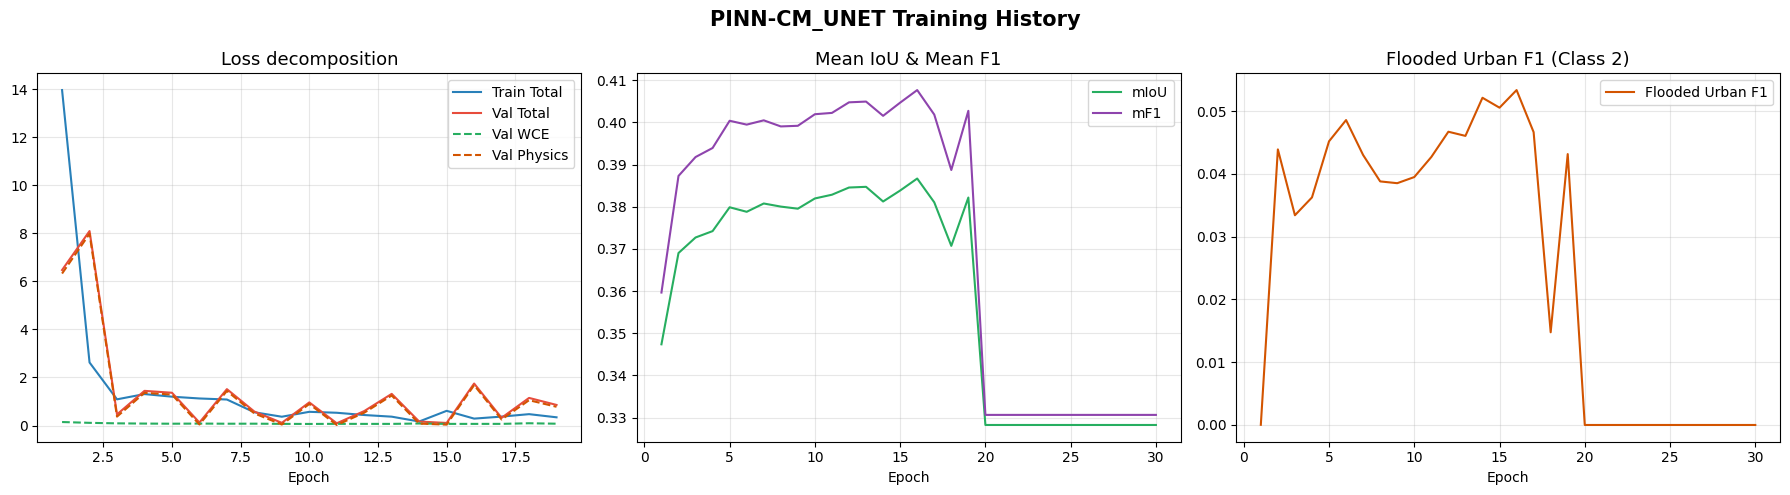

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ep = range(1, epochs + 1)

axes[0].plot(ep, history["train_loss"], label="Train Total",   color="#2980B9")
axes[0].plot(ep, history["val_loss"],   label="Val Total",     color="#E74C3C")
axes[0].plot(ep, history["val_wce"],    label="Val WCE",       color="#27AE60", linestyle="--")
axes[0].plot(ep, history["val_phys"],   label="Val Physics",   color="#D35400", linestyle="--")
axes[0].set_title("Loss decomposition", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["miou"], label="mIoU", color="#27AE60")
axes[1].plot(ep, history["mf1"],  label="mF1",  color="#8E44AD")
axes[1].set_title("Mean IoU & Mean F1", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["urban_f1"], label="Flooded Urban F1", color="#D35400")
axes[2].set_title("Flooded Urban F1 (Class 2)", fontsize=13)
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f"PINN-{backbone.upper()} Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"pinn_{backbone}_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## <span style="color:#3498DB;">7. Results & Visualisation</span>

Loading the best checkpoint and visualising predictions on 4 validation samples. For each sample we now show **four** panels rather than three, to make the physics constraint inspectable:

- **Col 1**: SAR image (during-flood VV band, grayscale)
- **Col 2**: Ground-truth mask (0: Non-Flooded, 1: Flooded Open, 2: Flooded Urban)
- **Col 3**: Double-bounce **physics mask** $\mathcal{M}_{db}$ — pixels where the electromagnetic constraint fires
- **Col 4**: Model prediction (after argmax)

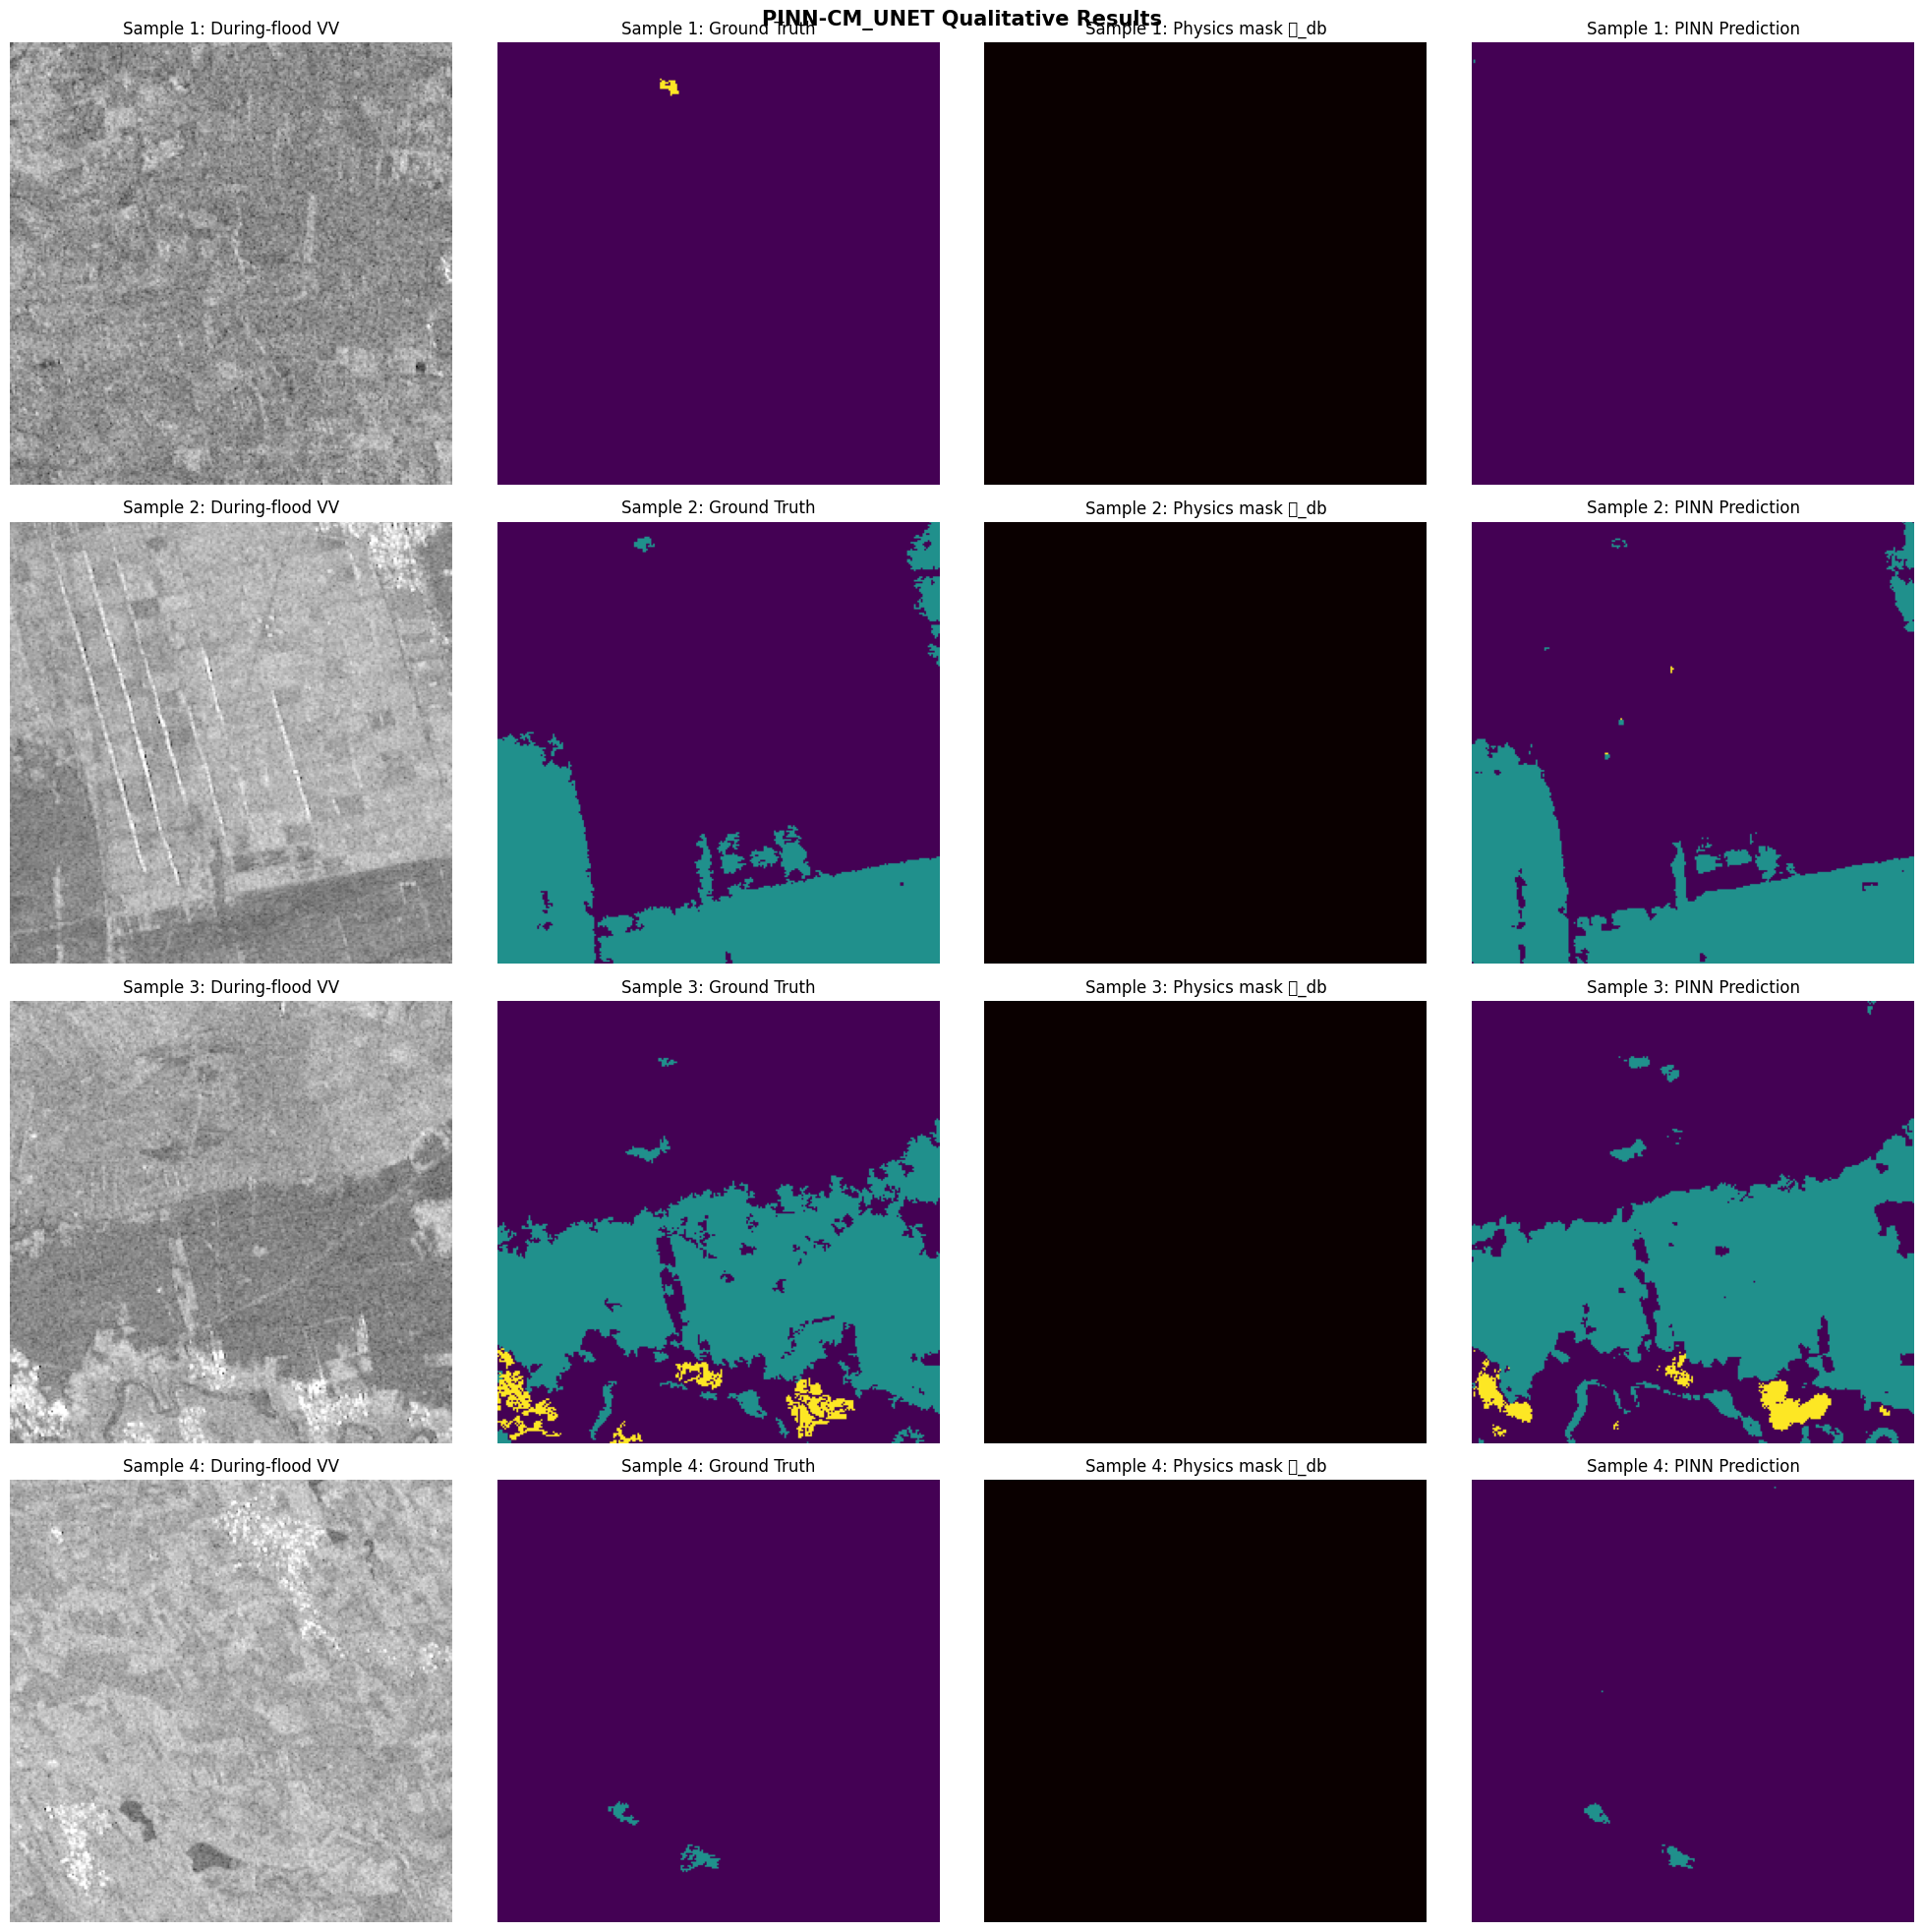

In [16]:
model.load_state_dict(torch.load(ckpt_best, map_location=device))
model.eval()

val_images, val_masks = next(iter(val_loader))
val_images_dev        = val_images.to(device)

with torch.no_grad():
    if scaler is not None:
        with torch.amp.autocast("cuda"):
            raw_preds = model(val_images_dev)
    else:
        raw_preds = model(val_images_dev)
    db_mask_vis = loss_fn.double_bounce_mask(val_images_dev).cpu().numpy()

pred_masks     = torch.argmax(raw_preds, dim=1).cpu().numpy()
val_images_cpu = val_images.numpy()
val_masks_cpu  = val_masks.numpy()

num_samples = min(4, batch_size)
fig, axes   = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

for i in range(num_samples):
    axes[i, 0].imshow(val_images_cpu[i, DUR_VV_IDX], cmap="gray")
    axes[i, 0].set_title(f"Sample {i+1}: During-flood VV")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(val_masks_cpu[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(db_mask_vis[i], cmap="hot", vmin=0, vmax=1)
    axes[i, 2].set_title(f"Sample {i+1}: Physics mask 𝓜_db")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(pred_masks[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 3].set_title(f"Sample {i+1}: PINN Prediction")
    axes[i, 3].axis("off")

plt.suptitle(f"PINN-{backbone.upper()} Qualitative Results", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"pinn_{backbone}_predictions.png", dpi=150, bbox_inches="tight")
plt.show()